In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
with open("outputs/2026-06-16/19-50-46/training_log.json", "r") as f:
    training_logs = json.load(f)["epoch_logs"]
training_logs

{'1': {'timestamp': '2026-06-16T19:50:53.160138',
  'current_learning_rate': 0.0005,
  'training': {'loss': 17.871219604677734,
   'reg': 10.750377666738327,
   'time_seconds': 5.454928159713745,
   'memory_reserved_mb': 1374.0,
   'memory_allocated_mb': 107.765625},
  'validation': {'metrics': {'MRR': 0.11650527268648148,
    'Hit@1': 0.09296070784330368,
    'Hit@3': 0.12254443019628525,
    'Hit@10': 0.15551917254924774},
   'time_seconds': 0.7343661785125732,
   'memory_reserved_mb': 1374.0,
   'memory_allocated_mb': 122.4140625}},
 '2': {'timestamp': '2026-06-16T19:51:00.013094',
  'current_learning_rate': 0.000499969466539211,
  'training': {'loss': 15.242808144821867,
   'reg': 25.646067711211895,
   'time_seconds': 5.217740774154663,
   'memory_reserved_mb': 1374.0,
   'memory_allocated_mb': 122.4140625},
  'validation': {'metrics': {'MRR': 0.11793620139360428,
    'Hit@1': 0.09260991215705872,
    'Hit@3': 0.12418147921562195,
    'Hit@10': 0.1596117913722992},
   'time_second

In [3]:
training_metrics = {
    epoch: {
        "loss": log["training"]["loss"],
        "Val MRR": log["validation"]["metrics"]["MRR"],
        "Val Hit@1": log["validation"]["metrics"]["Hit@1"],
        "Val Hit@3": log["validation"]["metrics"]["Hit@3"],
        "Val Hit@10": log["validation"]["metrics"]["Hit@10"],
    }
    for epoch, log in training_logs.items()
}
training_metrics = pd.DataFrame.from_dict(training_metrics, orient="index")
training_metrics
# pd.DataFrame.from_dict(training_loss, orient="index").plot()

,loss,Val MRR,Val Hit@1,Val Hit@3,Val Hit@10
1,17.871220,0.116505,0.092961,0.122544,0.155519
2,15.242808,0.117936,0.092610,0.124181,0.159612
3,14.440480,0.122091,0.096352,0.128274,0.163120
4,13.776856,0.124562,0.098807,0.130145,0.168849
5,13.432572,0.125618,0.099860,0.131899,0.168966
...,...,...,...,...,...
1995,4.936449,0.122295,0.092493,0.129093,0.179373
1996,4.959702,0.124619,0.094247,0.132484,0.183583
1997,4.979897,0.123237,0.092259,0.130847,0.181010
1998,4.943633,0.124112,0.094247,0.131665,0.180426


<Axes: title={'center': 'Loss'}>

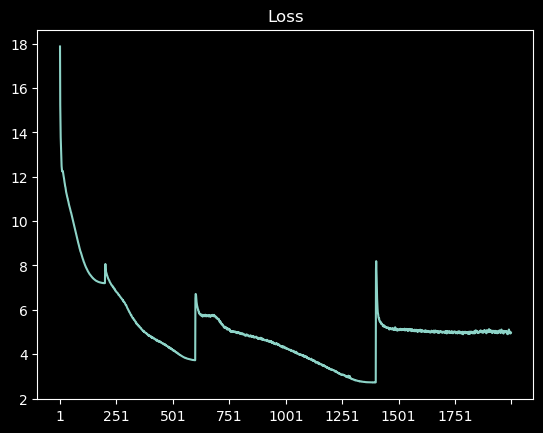

In [4]:
training_metrics["loss"].plot(title="Loss")

<Axes: title={'center': 'Validation Hit@10'}>

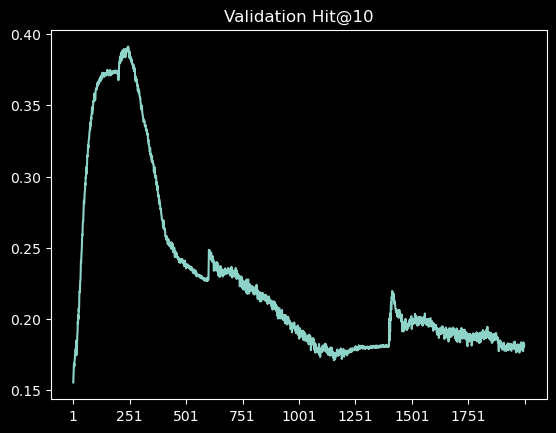

In [5]:
training_metrics["Val Hit@10"].plot(title="Validation Hit@10")

<Axes: title={'center': 'Validation MRR'}>

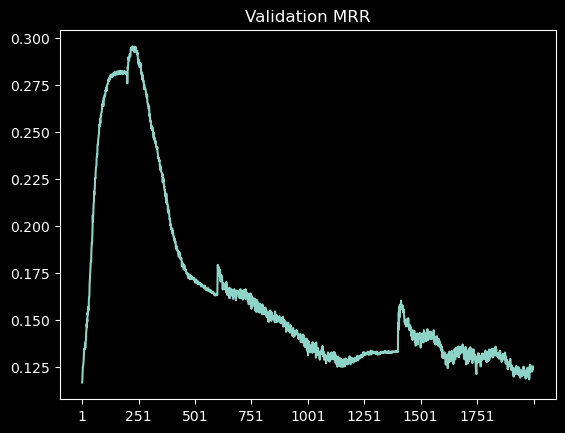

In [6]:
training_metrics["Val MRR"].plot(title="Validation MRR")